## Spotify Clustering

In [1]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# load the dataset

df = pd.read_csv(r"C:\Data Analyst\chtgpt\SpotifyFeatures.csv")

df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.910,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.737,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.131,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.326,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.225,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,38,0.03290,0.785,282447,0.683,0.000880,E,0.2370,-6.944,Minor,0.0337,113.830,4/4,0.969
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,44,0.26200,0.745,222442,0.704,0.000000,A,0.3330,-7.137,Major,0.1460,100.031,4/4,0.489


In [3]:
df.shape

(232725, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

### Exploratory Data Analysis

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,232725.0,41.127502,18.189948,0.00000,29.0000,43.000000,55.0000,100.000
acousticness,232725.0,0.368560,0.354768,0.00000,0.0376,0.232000,0.7220,0.996
danceability,232725.0,0.554364,0.185608,0.05690,0.4350,0.571000,0.6920,0.989
duration_ms,232725.0,235122.339306,118935.909299,15387.00000,182857.0000,220427.000000,265768.0000,5552917.000
energy,232725.0,0.570958,0.263456,0.00002,0.3850,0.605000,0.7870,0.999
instrumentalness,232725.0,0.148301,0.302768,0.00000,0.0000,0.000044,0.0358,0.999
liveness,232725.0,0.215009,0.198273,0.00967,0.0974,0.128000,0.2640,1.000
loudness,232725.0,-9.569885,5.998204,-52.45700,-11.7710,-7.762000,-5.5010,3.744
speechiness,232725.0,0.120765,0.185518,0.02220,0.0367,0.050100,0.1050,0.967
tempo,232725.0,117.666585,30.898907,30.37900,92.9590,115.778000,139.0540,242.903


In [6]:
df.isnull().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [7]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [8]:
num_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy','instrumentalness',
            'liveness', 'loudness', 'speechiness', 'tempo',  'valence']

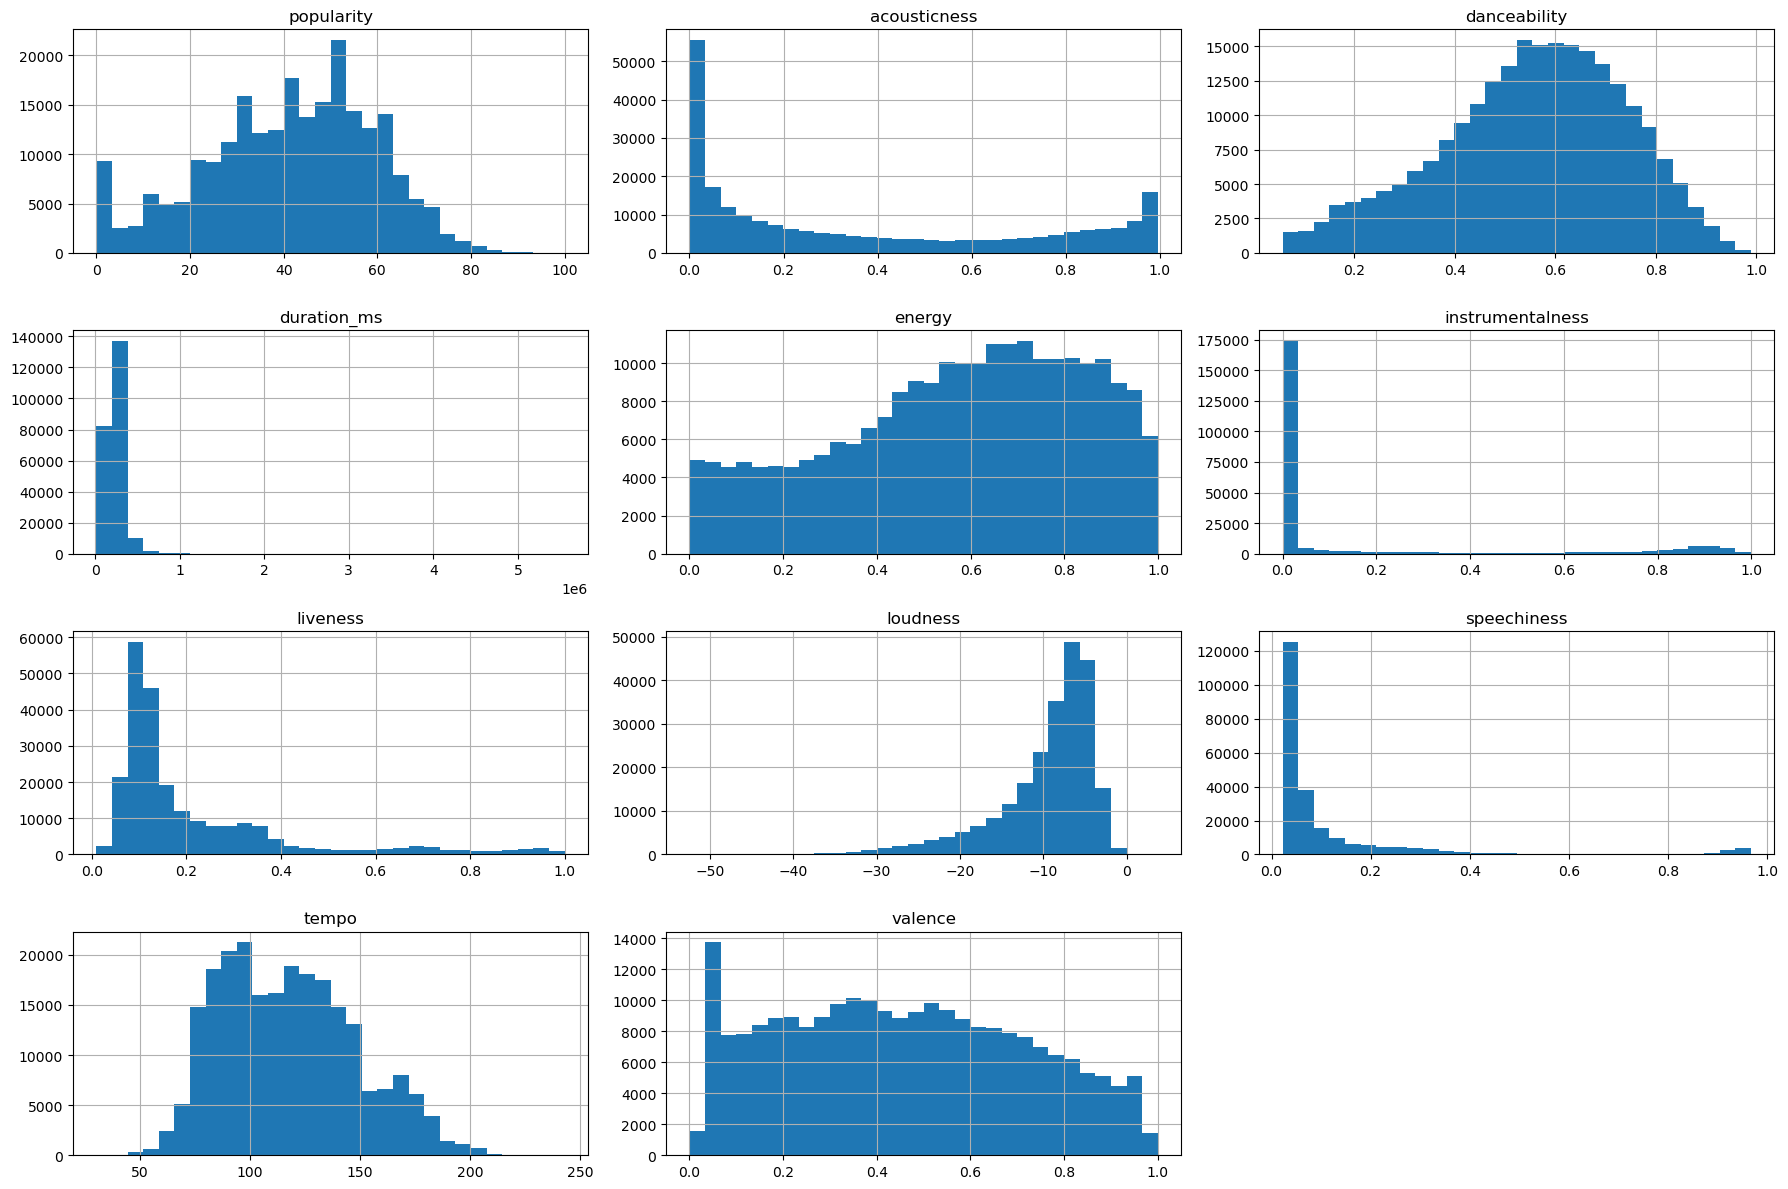

In [9]:
df[num_cols].hist(figsize=(18,12), bins=30)

plt.tight_layout()
plt.show()

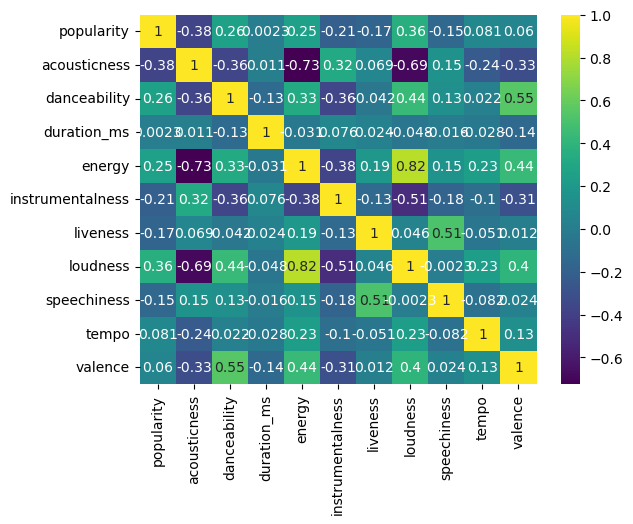

<Figure size 1800x1400 with 0 Axes>

In [10]:
# correlation
sns.heatmap(df[num_cols].corr(), annot = True, cmap='viridis')
plt.figure(figsize=(18,14))

plt.show()

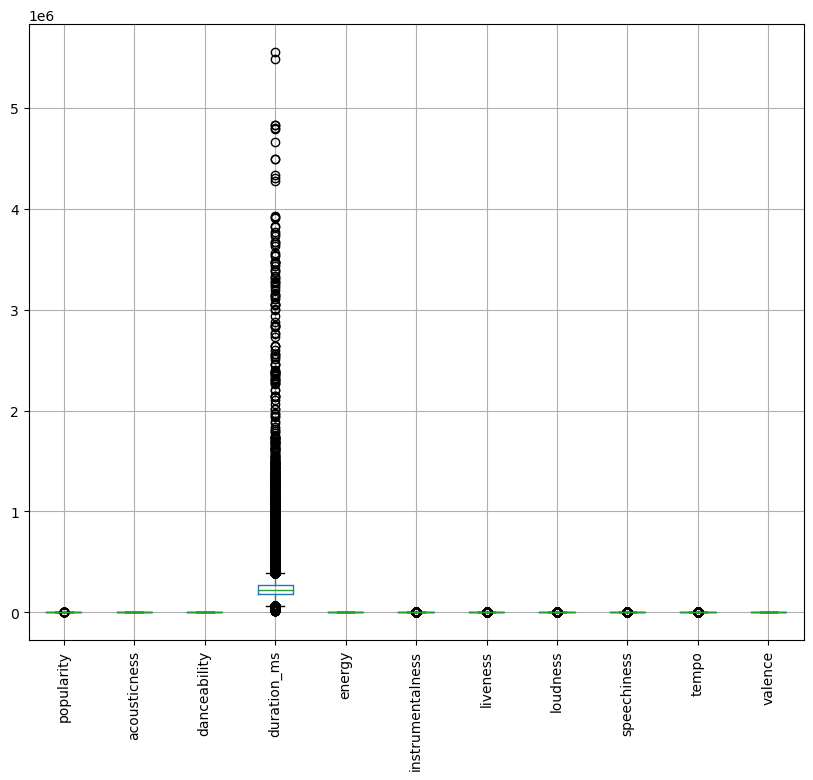

In [11]:
# boxplot to detect outliers
plt.figure(figsize=(10,8))
df[num_cols].boxplot(rot=90)
plt.show()

In [12]:
# feature selection

X = df[num_cols]

X = pd.DataFrame(X, columns=num_cols)
X.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
0,0,0.611,0.389,99373,0.910,0.000,0.3460,-1.828,0.0525,166.969,0.814
1,1,0.246,0.590,137373,0.737,0.000,0.1510,-5.559,0.0868,174.003,0.816
2,3,0.952,0.663,170267,0.131,0.000,0.1030,-13.879,0.0362,99.488,0.368
3,0,0.703,0.240,152427,0.326,0.000,0.0985,-12.178,0.0395,171.758,0.227
4,4,0.950,0.331,82625,0.225,0.123,0.2020,-21.150,0.0456,140.576,0.390


In [13]:
# scaling

scale = StandardScaler()
X_scaled = scale.fit_transform(X)

In [14]:
X_scaled = pd.DataFrame(X_scaled, columns=num_cols)

In [15]:
X_scaled.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05,2.327250e+05
mean,5.159812e-17,1.658467e-16,-4.885029e-17,-2.516553e-17,2.735616e-17,5.568933e-17,-2.796679e-16,-9.647932e-17,-8.646501e-17,-5.485888e-16,4.323251e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-2.261007e+00,-1.038880e+00,-2.680191e+00,-1.847514e+00,-2.167115e+00,-4.898185e-01,-1.035644e+00,-7.150008e+00,-5.312965e-01,-2.824947e+00,-1.749243e+00
25%,-6.667160e-01,-9.328945e-01,-6.431004e-01,-4.394421e-01,-7.058423e-01,-4.898185e-01,-5.931709e-01,-3.669631e-01,-4.531369e-01,-7.996282e-01,-8.379325e-01
50%,1.029416e-01,-3.849297e-01,8.962731e-02,-1.235571e-01,1.292150e-01,-4.896722e-01,-4.388376e-01,3.014051e-01,-3.809067e-01,-6.112155e-02,-4.197743e-02
75%,7.626480e-01,9.962575e-01,7.415395e-01,2.576659e-01,8.200350e-01,-3.715761e-01,2.470882e-01,6.783521e-01,-8.497840e-02,6.921753e-01,7.885844e-01
max,3.236547e+00,1.768595e+00,2.341688e+00,4.471153e+01,1.624727e+00,2.809741e+00,3.959158e+00,2.219650e+00,4.561473e+00,4.053111e+00,2.095950e+00


In [16]:
X_scaled.shape

(232725, 11)

In [17]:
# selecting the number for k in the k-means

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

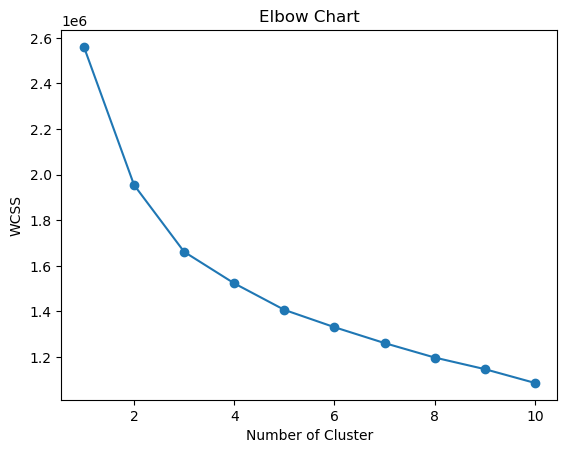

In [18]:
# plotting the elbow chart

plt.plot(range(1,11), wcss, marker='o')
plt.ylabel('WCSS')
plt.xlabel('Number of Cluster')
plt.title('Elbow Chart')
plt.show()

In [19]:
# training the model with the k value from the elbow chart

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)

kmeans.fit(X_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [20]:
# predict

clusters = kmeans.predict(X_scaled)

In [21]:
df['clusters'] = clusters

In [22]:
df.clusters.value_counts()

clusters
0    133030
2     57158
1     32317
3     10220
Name: count, dtype: int64

In [23]:
cluster_profile = df.groupby('clusters')[num_cols].mean().round(1)

cluster_profile

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
clusters,,,,,,,,,,,
0,46.9,0.1,0.6,232171.8,0.7,0.1,0.2,-6.2,0.1,124.5,0.6
1,26.1,0.9,0.3,258646.9,0.2,0.6,0.2,-20.5,0.0,102.6,0.2
2,39.8,0.6,0.6,227197.2,0.4,0.1,0.2,-10.8,0.1,113.8,0.4
3,20.7,0.8,0.6,243464.4,0.7,0.0,0.7,-12.0,0.9,98.3,0.4


In [27]:
from sklearn.metrics import silhouette_score

In [30]:
score = silhouette_score(X_scaled, clusters)

print(score)

0.18605185412941877


In [29]:
# save the df to a csv file for Tableau viz

#df.to_csv('Spotify_Cluster.csv', index= False)

PermissionError: [Errno 13] Permission denied: 'Spotify_Cluster.csv'